In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.linalg import expm

In [2]:
# Fysikaalisten vakioiden määrittely

phi_zero = 2.0678e-15 #Magneettivuon kvantti
hbar = 1.055e-34 #redusoitu Planckin vakio  

In [32]:
class Transmon:

    def __init__(self,E_C,E_J,N):

        self.E_C=E_C
        self.E_J=E_J
        self.N=N   

        self.phi = np.linspace(-np.pi, np.pi, N, endpoint=False) #vaiheoperaattori diskretisoituna välillä [-pi,pi] 1000 pisteeseen
        self.delta_phi = self.phi[1]-self.phi[0] #vaiheoperaattorin diskresitoitu askelväli

        M = np.eye(N,k=1)+np.eye(N,k=-1)-2*np.eye(N) #Muodostetaan numero-operaattorin neliön matriisiesitys differenssimenetelmällä

        n_squared = -M/(self.delta_phi**2)

        self.H_0 = 4*E_C*n_squared-E_J*np.diag(np.cos(self.phi)) #Hamiltonin operaattori

        energies, eigenstates = np.linalg.eigh(self.H_0) # Transmonin ominaisenergiat ja -tilat

        self.energies = energies
        self.eigenstates = eigenstates
        self.frequency = energies[1]-energies[0]

    def H_D_phibasis(self,A,f_d): #Ajettu Hamiltonin operaattori phi-kannassa (n_g:n muutos)

        M=np.eye(self.N,k=1)-np.eye(self.N,k=-1)

        def n_g(t): return (A/(8*self.E_C)+A**2) * np.cos(f_d * t)
        def offset_term(t): return 1j * n_g(t) * M / self.delta_phi
        def H_t(t): return self.H_0 + 4 * self.E_C * offset_term(t)

        return H_t
    
    def H_D_eigbasis(self,A,f_d,dim): #Ajettu Hamiltonin operaattori ominaiskannassa
 
        H_0 = np.diag(self.energies[0:dim]-self.energies[0])

        M = np.zeros((dim, dim))
        vals = np.sqrt(np.arange(1, dim))
        M[np.arange(dim-1), np.arange(1, dim)] = vals      
        M[np.arange(1, dim), np.arange(dim-1)] = vals

        def H_t(t): return H_0 + A*np.cos(f_d*t)*M

        return H_t
    

class time_evolution:

    def __init__(self,generator):
        self.generator = generator
    
    def U(self, t, dt): return expm(-1j * self.generator(t) * dt) #Aikaevoluutio-operaattori

    def U_floquet(self, period, N): #Floquet-operaattori

        t_vals_floquet=np.linspace(0,period,N)
        delta_t_floquet = t_vals_floquet[1]-t_vals_floquet[0]

        U_f = self.U(0, 0)
        for i in range(1, N): #Aikakehitysoperaattori yhdelle Floquet-jaksolle
            U_f = self.U(t_vals_floquet[i-1]+delta_t_floquet/2, delta_t_floquet) @ U_f
        return U_f

Transmonin määrittely

In [45]:
E_C = 0.3 #Varausenergia (GHz)
E_J = 8 #Josephsonin energia (GHz)

qubit=Transmon(E_C,E_J,500)

In [46]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[ 0.          4.05659603  7.75167711 11.07195123 14.16415697 17.39291685
 21.10944851 25.45470893 30.43826717 36.04620425 42.26833044]


### Aaltofunktiot

<function matplotlib.pyplot.show(close=None, block=None)>

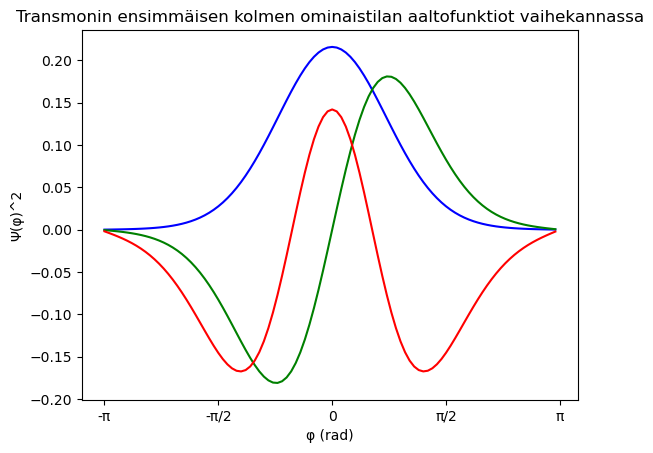

In [35]:
plt.plot(qubit.phi,qubit.eigenstates[:,0], 'b')
plt.plot(qubit.phi,qubit.eigenstates[:,1], 'g')
plt.plot(qubit.phi,qubit.eigenstates[:,2], 'r')

plt.xlabel('φ (rad)')
plt.xticks([-np.pi,-np.pi/2,0, np.pi/2,np.pi], ['-π','-π/2','0', 'π/2','π'])

plt.ylabel('Ψ(φ)^2')

plt.title('Transmonin ensimmäisen kolmen ominaistilan aaltofunktiot vaihekannassa')

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

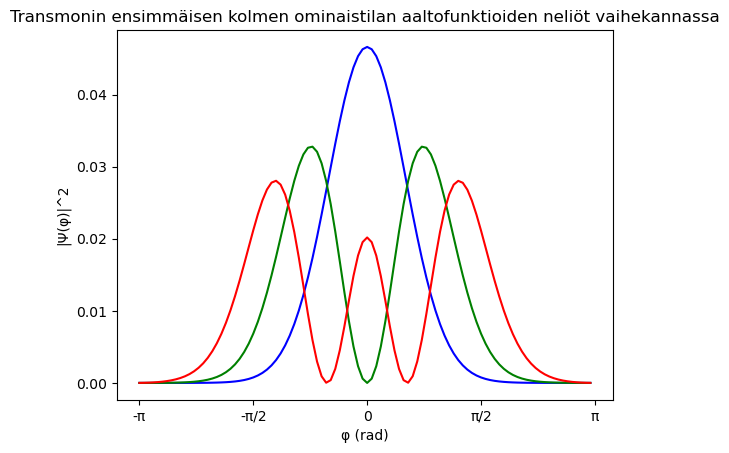

In [36]:
plt.plot(qubit.phi,qubit.eigenstates[:,0]**2, 'b')
plt.plot(qubit.phi,qubit.eigenstates[:,1]**2, 'g')
plt.plot(qubit.phi,qubit.eigenstates[:,2]**2, 'r')

plt.xlabel('φ (rad)')
plt.xticks([-np.pi,-np.pi/2,0, np.pi/2,np.pi], ['-π','-π/2','0', 'π/2','π'])

plt.ylabel('|Ψ(φ)|^2')

plt.title('Transmonin ensimmäisen kolmen ominaistilan aaltofunktioiden neliöt vaihekannassa')

plt.show

### Aikakehitys

Schrödingerin yhtälön numeerinen ratkaisu resonanssiajossa

In [68]:
A = 0.02*qubit.frequency #Ajava amplitudi
f_d = qubit.frequency #Ajotaajuus

N=2000 #Aika-avaruuden dimensio
t_vals=np.linspace(0,4*np.pi/A,N) #Diskretisoidaan aika välillä [0,2T_Rabi]
delta_t=(t_vals[1]-t_vals[0])

In [69]:
#Simulaatio ominaiskannassa

dim = 7

evolution_eigenbasis=time_evolution(qubit.H_D_eigbasis(A,f_d,dim))

psi_eig = np.zeros((N, dim), dtype=complex) #Alustetaan kubitin tila perustilaan
psi_eig[0,0] = 1

for i in range(1, N): #Aikakehitys
    psi_eig[i] = evolution_eigenbasis.U(t_vals[i-1]+delta_t/2, delta_t) @ psi_eig[i-1]

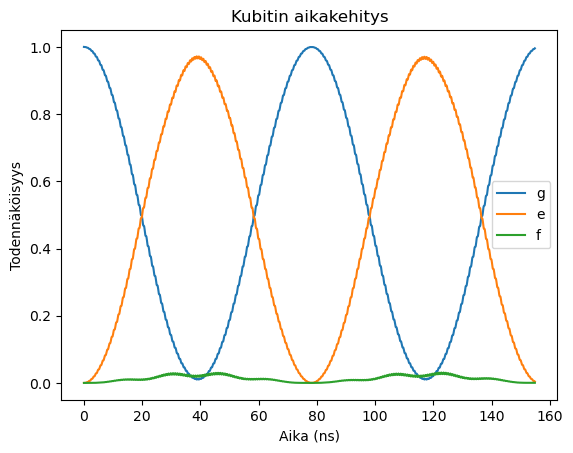

In [70]:
prob_g = np.abs(psi_eig[:, 0])**2
prob_e = np.abs(psi_eig[:, 1])**2
prob_f = np.abs(psi_eig[:, 2])**2

plt.plot(t_vals,prob_g)
plt.plot(t_vals,prob_e)
plt.plot(t_vals,prob_f)
plt.xlabel("Aika (ns)")
plt.ylabel("Todennäköisyys")
plt.title("Kubitin aikakehitys")
plt.legend(['g','e','f'])

Pauli-x portti havainnollistettuna Blochin pallolla (ensimmäinen neljännes yllä olevasta)

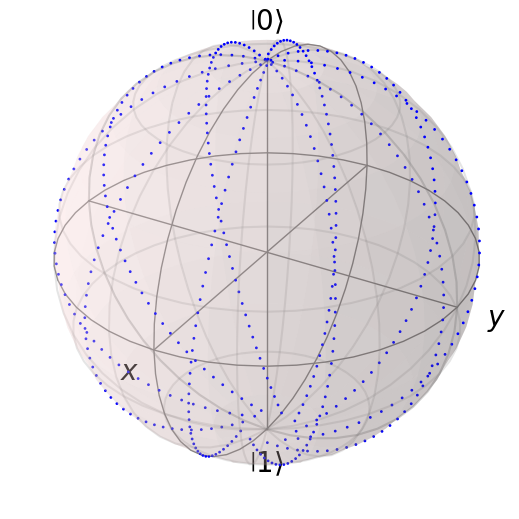

In [40]:
theta_vals=2*np.arccos(np.abs(psi_eig[:N//4,0])) #Napakulman arvot perustilan kertoimesta
phi_vals=np.angle(psi_eig[:N//4, 1])-np.angle(psi_eig[:N//4, 0]) #Vaakakulma on kertoimien argumenttien erotus

#Muunnetaan pallokoordinaatit karteesisiin koordinaatteihin, kun r=1
xpts=np.sin(theta_vals)*np.cos(phi_vals)
ypts=np.sin(theta_vals)*np.sin(phi_vals)
zpts=np.cos(theta_vals)

b=qt.Bloch()
b.point_size = [1,1,1,1]
b.add_points([xpts,ypts,zpts])
b.show()

Pauli-x portti havainnollistettuna Blochin pallolla koordinaatistossa, joka pyörii kubitin taajuudella

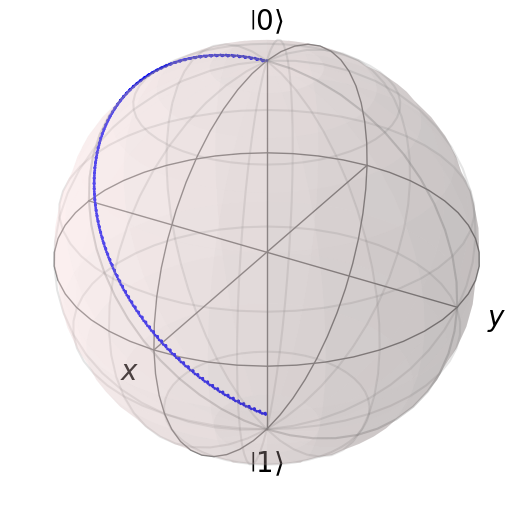

In [41]:
phi_vals_r = phi_vals+t_vals[:N//4]*(f_d) #Vaakakulman arvot koordinaatistossa, joka pyörii kubitin taajuudella

xpts_r=np.sin(theta_vals)*np.cos(phi_vals_r)
ypts_r=np.sin(theta_vals)*np.sin(phi_vals_r)

b_r=qt.Bloch()
b_r.point_size = [1,1,1,1]
b_r.add_points([xpts_r,ypts_r,zpts])
b_r.show()

In [42]:
#Simulaatio vaihekannassa

evolution_phibasis=time_evolution(qubit.H_D_phibasis(A,f_d))

psi = qubit.eigenstates[:,0]
psi_eig = np.zeros((N, 3), dtype=complex) #Alustetaan kubitin tila perustilaan
psi_eig[0] = np.array([1, 0, 0])

for i in range(1, N): #Aikakehitys
    psi = evolution_phibasis.U(t_vals[i-1]+delta_t/2, delta_t) @ psi
    for j in range(0,3): # Muunnos Hamiltonin operaattorin ominaiskantaan
        psi_eig[i,j]=np.vdot(psi,qubit.eigenstates[:,j])

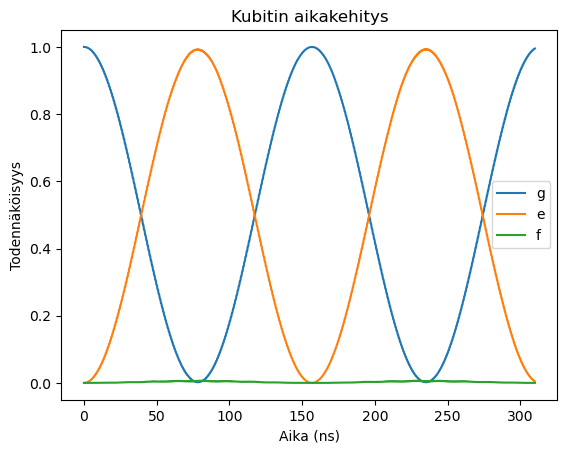

In [43]:
prob_g = np.abs(psi_eig[:, 0])**2
prob_e = np.abs(psi_eig[:, 1])**2
prob_f = np.abs(psi_eig[:, 2])**2

plt.plot(t_vals,prob_g)
plt.plot(t_vals,prob_e)
plt.plot(t_vals,prob_f)
plt.xlabel("Aika (ns)")
plt.ylabel("Todennäköisyys")
plt.title("Kubitin aikakehitys")
plt.legend(['g','e','f'])